In [5]:
##CVA Interval Breakdown
# CVA Model – Unilateral CVA for an Interest Rate Swap
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Discount Factor Curve (from Assignment #1)
df_table = {
    0.0: 1.0,      0.5: 0.989281, 1.0: 0.978181, 1.5: 0.966791,
    2.0: 0.955288, 2.5: 0.943209, 3.0: 0.93173,  3.5: 0.91939,
    4.0: 0.90741,  4.5: 0.895062, 5.0: 0.882882, 5.5: 0.870281,
    6.0: 0.857928
}

# Swap Parameters
notional  = 10_000_000   # EUR 10m notional
K         = 0.0265       # Fixed rate (2.65%)
pay_fixed = False        # False = Receive Fixed swap
n         = 10           # Number of semi-annual cash flows
tau       = 0.5          # Payment frequency (semi-annual)
T_end     = n * tau      # Swap maturity = 5.0 years

# Credit and Volatility Parameters
sigma = 0.2196    # Swaption implied volatility (from Assignment #1)
cs    = 0.02      # Counterparty credit spread (2.00%)
LGD   = 0.60      # Loss Given Default (60%)


# Helper: Parallel shift the discount factor curve
def bump_df_table(df_tbl, shift_bps):
    shift = shift_bps / 10_000
    return {t: df * np.exp(-shift * t) for t, df in df_tbl.items()}


# Helper: Black-76 Swaption Pricer
def swaption_black76(T_exp, K, sigma, df_tbl, tau, notional, T_end, pay_fixed):
    if T_exp >= T_end:
        return 0.0                        # No remaining swap tenor

    # Remaining payment dates after expiry
    payment_dates = np.round(np.arange(T_exp + tau, T_end + 1e-9, tau), 1)

    # Annuity factor  L = sum(tau * P(0, Ti))
    L = sum(tau * df_tbl[t] for t in payment_dates)
    if L == 0:
        return 0.0

    # Forward swap rate  F = [P(0, T_exp) - P(0, T_end)] / L
    F = (df_tbl[round(T_exp, 1)] - df_tbl[T_end]) / L

    # Black-76 d1 and d2
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T_exp) / (sigma * np.sqrt(T_exp))
    d2 = d1 - sigma * np.sqrt(T_exp)

    if pay_fixed:
        # Payer swaption:    N * L * [F * N(d1)  - K * N(d2)]
        return notional * L * (F * norm.cdf(d1)  - K * norm.cdf(d2))
    else:
        # Receiver swaption: N * L * [K * N(-d2) - F * N(-d1)]
        return notional * L * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


# Main CVA function – replication approach
def compute_cva(df_tbl, K, sigma, cs, LGD, tau, n, notional, pay_fixed, T_end):
    rows = []
    total_cva = 0.0

    for i in range(1, n + 1):
        ti = round(i * tau, 1)   # End of default interval i

        # EE_i: Expected Exposure approximated by swaption expiring at ti
        # Receive-fixed swap => receiver swaption (exposed when K > F, i.e. rates fall)
        # Pay-fixed swap     => payer swaption    (exposed when F > K, i.e. rates rise)
        ee_i = swaption_black76(ti, K, sigma, df_tbl, tau, notional, T_end, pay_fixed)

        # Marginal default probability in [t_{i-1}, t_i]
        # Flat hazard rate h = cs  =>  Survival probability SP(t) = exp(-cs * t)
        pd_i = np.exp(-cs * (ti - tau)) - np.exp(-cs * ti)

        # Interval CVA_i = LGD * EE_i * PD_i
        cva_i     = LGD * ee_i * pd_i
        total_cva += cva_i

        rows.append({
            'Interval':    i,
            'T_i (yrs)':   ti,
            'EE_i (EUR)':  round(ee_i,  2),
            'PD_i':        round(pd_i,  6),
            'CVA_i (EUR)': round(cva_i, 2)
        })

    return total_cva, pd.DataFrame(rows)


# Run base case
cva_base, cva_df = compute_cva(
    df_table, K, sigma, cs, LGD, tau, n, notional, pay_fixed, T_end
)

print("CVA Interval Breakdown")
print("=" * 65)
print(cva_df.to_string(index=False))
print("=" * 65)
print(f"Total CVA:  EUR {cva_base:,.2f}")

CVA Interval Breakdown
 Interval  T_i (yrs)  EE_i (EUR)     PD_i  CVA_i (EUR)
        1        0.5    92971.98 0.009950       555.05
        2        1.0    99124.18 0.009851       585.89
        3        1.5    97416.89 0.009753       570.07
        4        2.0    90474.72 0.009656       524.18
        5        2.5    81907.23 0.009560       469.82
        6        3.0    67559.50 0.009465       383.67
        7        3.5    54141.71 0.009371       304.41
        8        4.0    37112.96 0.009277       206.59
        9        4.5    19661.01 0.009185       108.35
       10        5.0        0.00 0.009094         0.00
Total CVA:  EUR 3,708.03


**CVA Model - Theory**

**1. Replication Approach**

The time to maturity is split into n = 10 intervals (one per cash flow).
For each interval i:

CVA_i = LGD × EE_i × PD_i

Total CVA = Σ CVA_i

**2. Expected Exposure (EE_i)**

EE_i is approximated by a Receiver Swaption expiring at T_i on the residual swap from T_i to T_end.

For a Receive-Fixed swap, the bank is exposed when rates fall below K (positive MTM).
This matches the payoff of a Receiver Swaption:

EE_i = N × L_i × [K × N(−d2) − F_i × N(−d1)]

L_i = Σ τ × P(0, T_j)   for T_j from T_i+τ to T_end   (Annuity factor)

F_i = [P(0, T_i) − P(0, T_end)] / L_i                   (Forward swap rate)

d1 = [ln(F_i / K) + 0.5 × σ² × T_i] / (σ × √T_i)

d2 = d1 − σ × √T_i

**3. Marginal Default Probability (PD_i)**

Flat hazard rate h = cs:

SP(t) = exp(−cs × t)

PD_i = SP(T_{i−1}) − SP(T_i) = exp(−cs × T_{i−1}) − exp(−cs × T_i)

**4. Loss Given Default (LGD)**

LGD = 60%. Fraction of positive

In [6]:
##CVA Sensitivities

# 1. CVA PV01 – bump interest rates +1bp
df_pv01  = bump_df_table(df_table, 1)
cva_pv01 = compute_cva(df_pv01, K, sigma, cs, LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_base

# 2. CVA Vega – bump swaption vol +1bp (0.01%)
cva_vega = compute_cva(df_table, K, sigma+0.0001, cs, LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_base

# 3. CVA CS01 – bump credit spread +1bp
cva_cs01 = compute_cva(df_table, K, sigma, cs+0.0001, LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_base

print(f"CVA Summary – EUR 10m Receive-Fixed IRS")
print(f"(K=2.65%,  CS=2.00%,  LGD=60%,  sigma=21.96%)")
print("=" * 55)
print(f"CVA        = EUR {cva_base:>10,.2f}   (base CVA)")
print(f"CVA PV01   = EUR {cva_pv01:>10,.2f}   (change per +1bp in rates)")
print(f"CVA Vega   = EUR {cva_vega:>10,.4f}   (change per +1bp in vol)")
print(f"CVA CS01   = EUR {cva_cs01:>10,.2f}   (change per +1bp in credit spread)")
print("=" * 55)

CVA Summary – EUR 10m Receive-Fixed IRS
(K=2.65%,  CS=2.00%,  LGD=60%,  sigma=21.96%)
CVA        = EUR   3,708.03   (base CVA)
CVA PV01   = EUR     -58.54   (change per +1bp in rates)
CVA Vega   = EUR     1.5798   (change per +1bp in vol)
CVA CS01   = EUR      17.88   (change per +1bp in credit spread)


**CVA Sensitivities - Theory**

All sensitivities use the bump-and-reprice (finite difference) method.

**1. CVA PV01 (Interest Rate Sensitivity)**

Parallel shift of zero-rate curve by +1bp:  P_new(t) = P(t) × exp(−0.0001 × t)

CVA PV01 = CVA(rates + 1bp) − CVA(base)

When rates rise, forward rates F_i increase, pushing receiver swaptions
further out-of-the-money. EE falls → CVA PV01 is negative.

**2. CVA Vega (Volatility Sensitivity)**

CVA Vega = CVA(σ + 0.0001) − CVA(base)   [+1bp = 0.01% change in σ]

Higher vol raises all swaption values → higher EE → higher CVA.
CVA Vega is positive. Multiply × 100 for sensitivity per 1% vol move.

**3. CVA CS01 (Credit Spread Sensitivity)**

CVA CS01 = CVA(cs + 0.0001) − CVA(base)

Wider credit spread → higher marginal PD_i → higher CVA. CVA CS01 is positive.

CVA CS01 = LGD × Σ EE_i × dPD_i/d(cs) × 0.0001

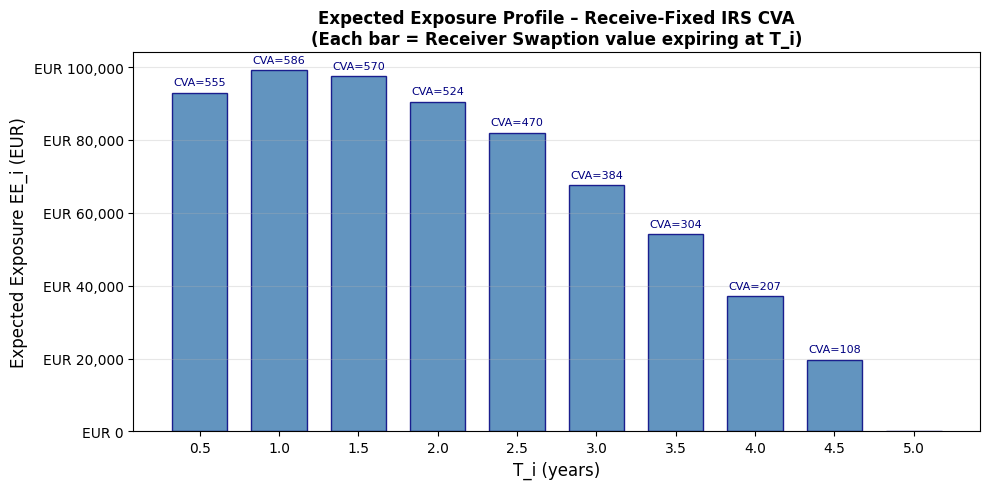

In [7]:
# Chart 1 – Expected Exposure Profile

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(
    cva_df['T_i (yrs)'], cva_df['EE_i (EUR)'],
    width=0.35, color='steelblue', alpha=0.85, edgecolor='navy'
)
ax1.set_xlabel('T_i (years)', fontsize=12)
ax1.set_ylabel('Expected Exposure EE_i (EUR)', fontsize=12)
ax1.set_title(
    'Expected Exposure Profile – Receive-Fixed IRS CVA\n'
    '(Each bar = Receiver Swaption value expiring at T_i)',
    fontsize=12, fontweight='bold'
)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'EUR {x:,.0f}'))
ax1.set_xticks(cva_df['T_i (yrs)'])
ax1.grid(axis='y', alpha=0.3)

# Annotate each bar with CVA_i
for _, row in cva_df.iterrows():
    if row['EE_i (EUR)'] > 0:
        ax1.text(
            row['T_i (yrs)'], row['EE_i (EUR)'] + 1500,
            f"CVA={row['CVA_i (EUR)']:.0f}",
            ha='center', va='bottom', fontsize=8, color='navy'
        )

plt.tight_layout()
plt.show()

**Chart 1 – Expected Exposure Profile**

Each bar shows EE_i = the value of a Receiver Swaption expiring at T_i.
The annotation on each bar shows the interval CVA_i contribution.

Key observations:
- EE rises from T=0.5 to T=1.0 because the longer residual tenor adds more time value
- EE then declines steadily as the residual swap tenor shortens toward zero
- At T=5.0 the remaining swap has zero tenor → EE = 0 → CVA_10 = 0
- The swap is slightly in-the-money (K=2.65% vs par rate ~2.50%),
  giving all swaptions positive intrinsic value from the outset

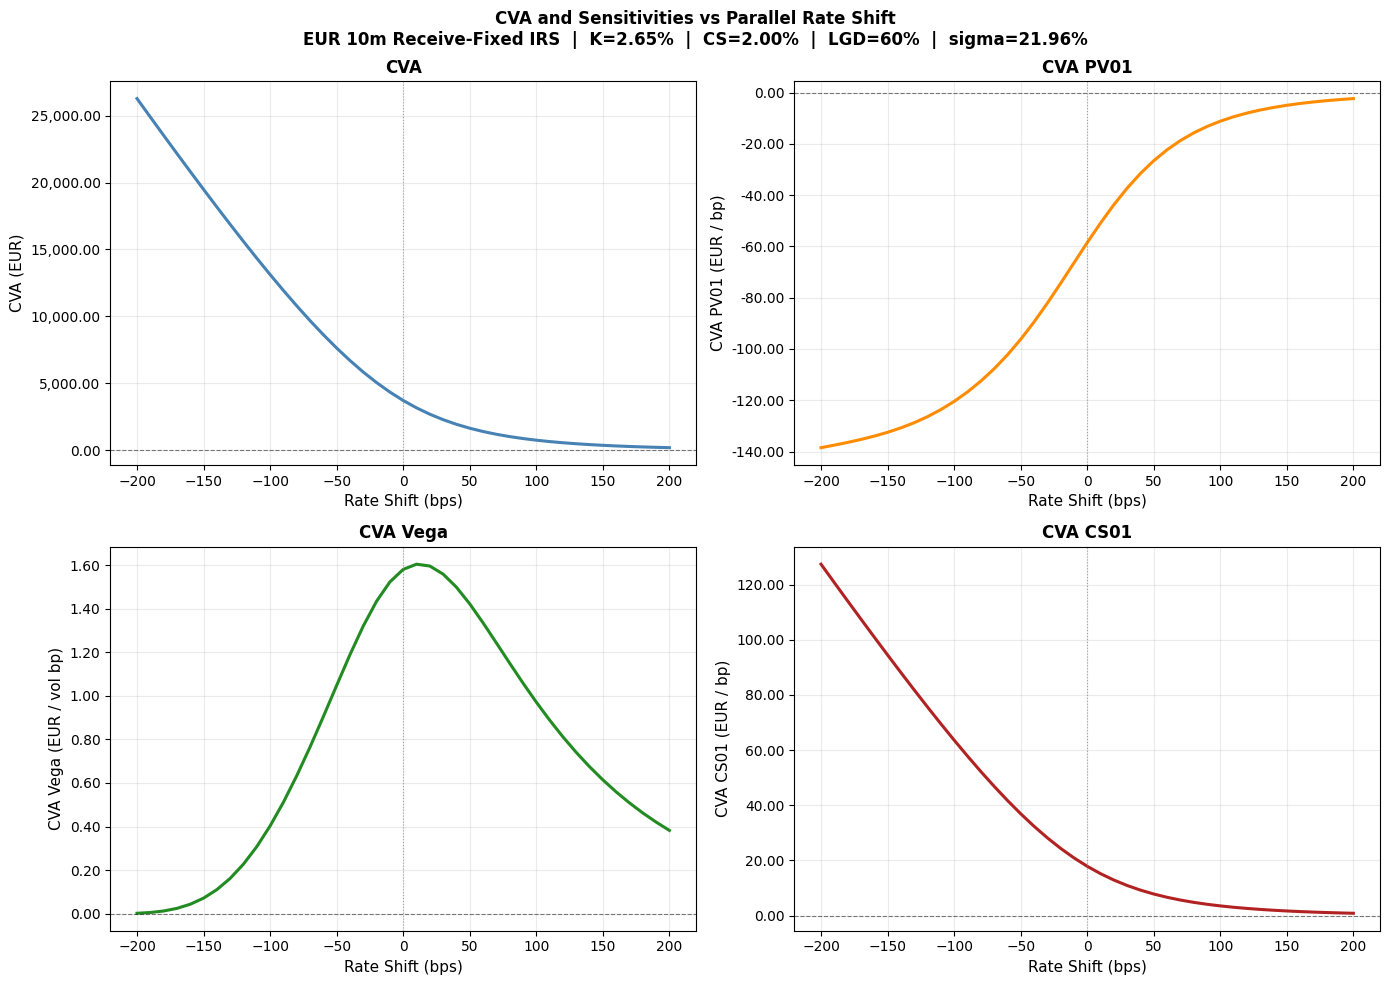

 Shift(bps)    CVA(EUR)   PV01(EUR)   Vega(EUR)   CS01(EUR)
------------------------------------------------------------
       -200   26,279.52     -138.49      0.0023      127.38
       -100   13,120.74     -120.46      0.4030       63.62
        -50    7,627.96      -96.25      1.0476       36.94
          0    3,708.03      -58.54      1.5798       17.88
         50    1,633.85      -26.58      1.4217        7.83
        100      739.10      -11.17      0.9710        3.52
        200      179.60       -2.36      0.3825        0.85


In [8]:
# Chart 2 – CVA and Sensitivities vs Parallel Rate Shift

shifts_bps = np.arange(-200, 201, 10)
cva_vals, pv01_vals, vega_vals, cs01_vals = [], [], [], []

for bps in shifts_bps:
    df_s  = bump_df_table(df_table, bps)
    cva_s = compute_cva(df_s, K, sigma, cs, LGD, tau, n, notional, pay_fixed, T_end)[0]
    cva_vals.append(cva_s)
    pv01_vals.append(compute_cva(bump_df_table(df_s, 1), K, sigma,        cs,        LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_s)
    vega_vals.append(compute_cva(df_s,                   K, sigma+0.0001, cs,        LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_s)
    cs01_vals.append(compute_cva(df_s,                   K, sigma,        cs+0.0001, LGD, tau, n, notional, pay_fixed, T_end)[0] - cva_s)

fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle(
    'CVA and Sensitivities vs Parallel Rate Shift\n'
    'EUR 10m Receive-Fixed IRS  |  K=2.65%  |  CS=2.00%  |  LGD=60%  |  sigma=21.96%',
    fontsize=12, fontweight='bold'
)

panels = [
    (cva_vals,  axes[0,0], 'CVA (EUR)',               'steelblue',   'CVA'),
    (pv01_vals, axes[0,1], 'CVA PV01 (EUR / bp)',     'darkorange',  'CVA PV01'),
    (vega_vals, axes[1,0], 'CVA Vega (EUR / vol bp)', 'forestgreen', 'CVA Vega'),
    (cs01_vals, axes[1,1], 'CVA CS01 (EUR / bp)',     'firebrick',   'CVA CS01'),
]

for vals, ax, ylabel, color, title in panels:
    ax.plot(shifts_bps, vals, color=color, linewidth=2.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray',  linewidth=0.8, linestyle=':',  alpha=0.7)
    ax.set_xlabel('Rate Shift (bps)', fontsize=11)
    ax.set_ylabel(ylabel,             fontsize=11)
    ax.set_title(title,               fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.2f}'))
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Shift(bps)':>11} {'CVA(EUR)':>11} {'PV01(EUR)':>11} {'Vega(EUR)':>11} {'CS01(EUR)':>11}")
print("-" * 60)
for bps in [-200, -100, -50, 0, 50, 100, 200]:
    idx = list(shifts_bps).index(bps)
    print(f"{bps:>11} {cva_vals[idx]:>11,.2f} {pv01_vals[idx]:>11,.2f} {vega_vals[idx]:>11,.4f} {cs01_vals[idx]:>11,.2f}")

**Chart 2 – Sensitivity Analysis**

**CVA vs Rate Shift (top-left)**
CVA is a convex, decreasing function of interest rates.
When rates fall, receiver swaptions move deeper in-the-money and EE rises.
When rates rise sharply, swaptions go out-of-the-money and CVA approaches zero.

**CVA PV01 vs Rate Shift (top-right)**
CVA PV01 is always negative for a receive-fixed swap.
The magnitude is largest when rates are low (swaptions deep ITM, high delta)
and approaches zero when rates are very high (swaptions OTM).

**CVA Vega vs Rate Shift (bottom-left)**
CVA Vega is always positive.
It is largest when rates are low and swaptions are near-the-money,
and decreases as swaptions move out-of-the-money at higher rates.

**CVA CS01 vs Rate Shift (bottom-right)**
CVA CS01 is always positive and tracks CVA itself proportionally.
A wider credit spread increases PD_i at all intervals,
so CS01 is higher when base CVA is higher (i.e. at low rates).